In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from glob import glob

In [2]:
image_paths = sorted(glob('./data/lab2/frame*.jpg'))
images = [cv.imread(p) for p in image_paths]
gray_images = [cv.cvtColor(img, cv.COLOR_BGR2GRAY) for img in images]
img1 = gray_images[0]
img2 = gray_images[1]
img3 = gray_images[2]
img4 = gray_images[3]
img5 = gray_images[4]
img6 = gray_images[5]
img7 = gray_images[6]
img8 = gray_images[7]

windowSize = 5
window = np.ones([windowSize, windowSize])

In [46]:
def gaussian(m,n,sigma): #заполнение ядра Гаусса
    gaussian_kernel = np.zeros((m,n))
    for x in range(-m//2,m//2+1):
        for y in range(-n//2,n//2+1):
            gaussian_kernel[x+m//2][y+n//2] = np.exp(-(x**2+y**2)/(2*sigma**2))*(1/(2*np.pi*(sigma**2)))
    return gaussian_kernel

def normal_gaus(gaus):
    m = len(gaus)
    n = len(gaus[0])
    sum = 0
    for i in range (m):
        for j in range (n):
            sum += gaus[i][j]
    return gaus/sum
def gaussian_filter(image,sigma, m=3,n=3):
    
    kernel = gaussian(m, n, sigma)
    kernel = normal_gaus(kernel)
    h, w = image.shape
    result = np.zeros_like(image)
    padded = reflect_borders(image, n)
    for i in range(h):
        for j in range(w):
            # Извлечение окна (срез)
            window = padded[i:i + m, j:j + n]
            result[i, j] = np.sum(window * kernel)
            
    return result

In [47]:
def reflect_borders(image, n): #image - изображение (не RGB либо отдельный канал), n - размерность ядра свертки
    h, w = image.shape
    conv_image = np.zeros((h+n//2+n//2, w+n//2+n//2),dtype=image.dtype)
    for j in range(h):
        for k in range(w):
            conv_image[j+n//2][k+n//2] = image[j][k]
    for j in range (n//2):
        for k in range(w+n//2+n//2):
            if (k < n//2):
                conv_image[j][k] = image[0][0]
            elif (k-n//2 >= w):
                conv_image[j][k] = image[0][w-1]
            elif (k < w+n//2):
                conv_image[j][k] = image[0][k-n//2]
    for j in range (h+n//2, h+n//2+n//2):
        for k in range(w+n//2+n//2):
            if (k < n//2):
                conv_image[j][k] = image[h-1][0]
            elif (k-n//2 >= w):
                conv_image[j][k] = image[h-1][w-1]
            elif (k < w+n//2):
                conv_image[j][k] = image[h-1][k-n//2]
    for j in range (n//2):
        for k in range(n//2 ,h+n//2):
            if (k-n//2 >= h):
                conv_image[k][j] = image[h-1][w-1]
            elif (k < h+n//2):
                conv_image[k][j] = image[k-n//2][0]
    for j in range (w+n//2, w+n//2+n//2):
        for k in range(n//2 ,h+n//2):
            if (k-n//2 >= h):
                conv_image[k][j] = image[h-1][w-1]
            elif (k < h+n//2):
                conv_image[k][j] = image[k-n//2][0]
    return conv_image

In [48]:
def convolution(image,window):
    start = int((windowSize-1)/2)
    result = np.zeros((image.shape))
    for i in range(start,image.shape[0]-start):
        for j in range(start,image.shape[1]-start):
            result[i,j] = np.sum(image[i-start:i+start+1,j-start:j+start+1]*window)
    return result
def local_max(e,window):
    start = int((windowSize-1)/2)
    result = np.zeros((e.shape))
    corner = dict()
    for i in range(start,e.shape[0]-start):
        for j in range(start,e.shape[1]-start):
            x = e[i-start:i+start+1,j-start:j+start+1]
            if (e[i][j] == np.max(x)):
                corner[e[i][j]] = [j,i]
    return corner
def corner_detect(image, nCorners, windowSize):
    corners = []
    gauss_img = gaussian_filter(image, 3, 5, 5)
    dy,dx = np.gradient(gauss_img)
    window = np.ones((windowSize, windowSize))
    c_xx = convolution(dx*dx,window)
    c_yy = convolution(dy*dy,window)
    c_xy = convolution(dx*dy,window)
    e = np.zeros((gauss_img.shape))
    for i in range(gauss_img.shape[0]):
        for j in range(gauss_img.shape[1]):
            c = np.array([[c_xx[i][j], c_xy[i][j]], [c_xy[i][j], c_yy[i][j]]])
            l, v = np.linalg.eig(c)
            e[i][j] = np.min(l)
    corner = local_max(e,window)
    for key in sorted(corner.keys(),reverse=True):
        corners.append(corner[key])
    return np.array(corners[0:nCorners])

In [49]:
corners = []
for i in range (len(gray_images)):
    corners.append(corner_detect(gray_images[i], 30, 5))
corners_img1 = corner_detect(img1, 50, 5)

In [66]:
img_copy = cv.cvtColor(img1.copy(), cv.COLOR_GRAY2RGB)
for (x, y) in corners[0]:
    cv.circle(img_copy, (x, y), radius=3, color=(255, 0, 0), thickness=2)
img_copy1 = cv.cvtColor(img2.copy(), cv.COLOR_GRAY2RGB)
for (x, y) in corners[1]:
    cv.circle(img_copy1, (x, y), radius=3, color=(255, 0, 0), thickness=2)

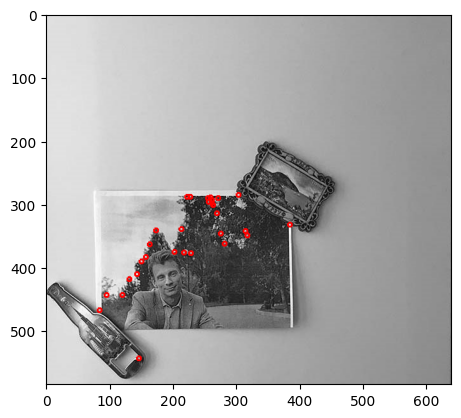

In [67]:
plt.imshow(img_copy)

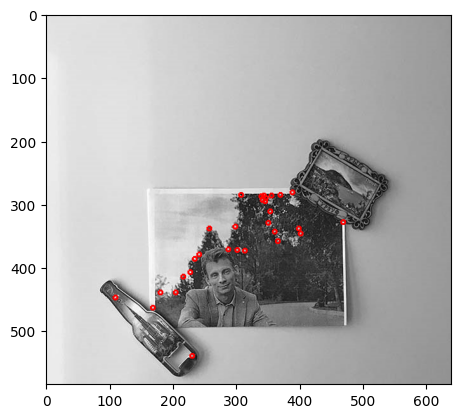

In [68]:
plt.imshow(img_copy1)

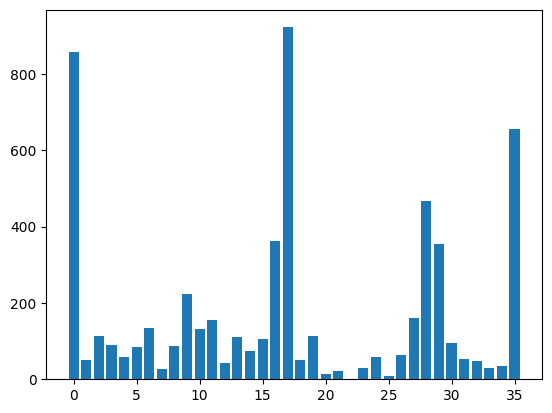

In [86]:
def gradient_orientation(image, sigma=1.0):
    """
    Вычисление модуля и направления градиента для каждого пикселя.
    Возвращает magnitude, angle (в градусах, 0-360).
    """
    smoothed = gaussian_filter(image.astype(np.float32), sigma, 3, 3)
    
    # Простые разности (центральные)
    dy, dx = np.gradient(smoothed)
    magnitude = np.sqrt(dx**2 + dy**2)
    angle = np.rad2deg(np.arctan2(dy, dx)) % 360  # угол от 0 до 360
    return magnitude, angle

def orientation_histogram(magnitude, angle, bins=36):
    """
    Строит взвешенную гистограмму направлений для всего патча.
    magnitude, angle - одномерные массивы (после flatten)
    bins - число бинов на 360 градусов.
    Возвращает гистограмму.
    """
    hist = np.zeros(bins, dtype=np.float32)
    bin_width = 360.0 / bins
    for mag, ang in zip(magnitude, angle):
        # Определяем индекс бина
        bin_idx = int(ang // bin_width)
        if bin_idx >= bins:
            bin_idx = bins - 1
        hist[bin_idx] += mag
    return hist
kkk = 0
def gaussian_weight(distance, sigma):
    """Гауссов вес для пикселя в зависимости от расстояния до центра патча."""
    return np.exp(- (distance**2) / (2 * sigma**2))
def sift_descriptor_single_point(image, x, y, patch_size=16, num_blocks=4, bins=8, sigma_gradient=1.0):
    """
    Вычисляет SIFT-подобный дескриптор для одной ключевой точки (x, y).
    Параметры:
        image: grayscale изображение (2D numpy array)
        x, y: координаты центра (целые числа)
        patch_size: размер квадратного патча (должен быть кратен num_blocks)
        num_blocks: число блоков в строке/столбце (итого блоков num_blocks^2)
        bins: число бинов гистограммы направлений (обычно 8)
        sigma_gradient: параметр сглаживания для вычисления градиента
    Возвращает:
        дескриптор - одномерный массив длины num_blocks * num_blocks * bins
        или None, если патч выходит за границы изображения
    """
    half = patch_size // 2
    # Проверка границ
    if (y - half < 0) or (y + half >= image.shape[0]) or (x - half < 0) or (x + half >= image.shape[1]):
        return None
    
    # Вырезаем патч
    patch = image[y-half:y+half, x-half:x+half].astype(np.float32)
    
    # Вычисляем градиенты для патча
    mag_patch, ang_patch = gradient_orientation(patch, sigma_gradient)
    
    # ---- Определение главной ориентации ----
    # Строим гистограмму направлений для всего патча (36 бинов)
    hist_global = orientation_histogram(mag_patch.flatten(), ang_patch.flatten(), bins=36)
    global kkk
    if kkk == 0:
        plt.bar(list(range(36)), hist_global)
        kkk = 1
    # Находим максимум (пик)
    peak_idx = np.argmax(hist_global)
    # Интерполяция для более точного угла (можно пропустить для простоты)
    main_angle = peak_idx * (360.0 / 36)  # центральное значение бина
    
    # ---- Поворот координат ----
    # Для каждого пикселя патча нужно знать его координаты относительно центра
    # и повернуть их на -main_angle, чтобы дескриптор был инвариантен к повороту.
    # Создаём сетку координат (в системе центра патча)
    ys, xs = np.meshgrid(np.arange(patch_size), np.arange(patch_size), indexing='ij')
    # Смещения от центра (в пикселях)
    y_shift = ys - half
    x_shift = xs - half
    
    # Поворачиваем смещения
    cos_angle = np.cos(np.radians(main_angle))
    sin_angle = np.sin(np.radians(main_angle))
    x_rot =  x_shift * cos_angle + y_shift * sin_angle
    y_rot = -x_shift * sin_angle + y_shift * cos_angle
    
    
    # ---- Разбиение на блоки ----
    block_size = patch_size / num_blocks  # размер одного блока (может быть нецелым)
    descriptor = []
    
    # Гауссово окно для взвешивания (вес убывает от центра)
    weight_sigma = patch_size / 2.0  # стандартное отклонение (можно настроить)
    weights = gaussian_weight(np.sqrt(x_shift**2 + y_shift**2), weight_sigma)
    
    # Для каждого блока
    for block_i in range(num_blocks):
        for block_j in range(num_blocks):
            # Границы блока в повёрнутых координатах (от -half до half)
            left = -half + block_i * block_size
            right = -half + (block_i + 1) * block_size
            top = -half + block_j * block_size
            bottom = -half + (block_j + 1) * block_size
            
            # Выбираем пиксели, попадающие в этот блок
            # Используем маску: (x_rot >= left) & (x_rot < right) & (y_rot >= top) & (y_rot < bottom)
            # Из-за вещественных координат нужно аккуратно с границами, но для простоты используем центральные точки пикселей
            mask = (x_rot >= left) & (x_rot < right) & (y_rot >= top) & (y_rot < bottom)
            
            # Массивы модуля и угла для этих пикселей
            mag_block = mag_patch[mask]
            ang_block = ang_patch[mask]
            weight_block = weights[mask]
            
            if len(mag_block) == 0:
                descriptor.extend([0] * bins)
                continue
            
            # Корректировка угла относительно главной ориентации
            ang_relative = (ang_block - main_angle) % 360
            
            # Строим гистограмму для блока (bins бинов)
            hist_block = np.zeros(bins, dtype=np.float32)
            bin_width = 360.0 / bins
            for mag, ang, w in zip(mag_block, ang_relative, weight_block):
                bin_idx = int(ang // bin_width)
                if bin_idx >= bins:
                    bin_idx = bins - 1
                hist_block[bin_idx] += mag * w
            
            descriptor.extend(hist_block)
    
    descriptor = np.array(descriptor, dtype=np.float32)
    
    # Нормализация (L2)
    norm = np.linalg.norm(descriptor)
    if norm > 0:
        descriptor /= norm
    # Отсечение больших значений (как в SIFT, обычно 0.2)
    descriptor = np.clip(descriptor, 0, 0.2)
    # Повторная нормализация после отсечения
    norm = np.linalg.norm(descriptor)
    if norm > 0:
        descriptor /= norm
    
    return descriptor

def extract_sift_descriptors(image, points, patch_size=16, num_blocks=4, bins=8):
    """
    Извлекает SIFT-подобные дескрипторы для списка точек.
    image: grayscale изображение (numpy array)
    points: список кортежей (x, y) – целочисленные координаты
    patch_size, num_blocks, bins – параметры дескриптора
    Возвращает массив дескрипторов формы (N, num_blocks*num_blocks*bins)
    """
    descriptors = []
    for (x, y) in points:
        desc = sift_descriptor_single_point(image, x, y, patch_size, num_blocks, bins)
        if desc is not None:
            descriptors.append(desc)
    return np.array(descriptors)
all_descriptors = []
for i in range (len(gray_images)):
    all_descriptors.append(extract_sift_descriptors(gray_images[i], corners[i])) 

In [80]:
def match_descriptors(desc1, desc2, ratio_thresh=0.75):
    """
    Сопоставление дескрипторов с использованием Lowe's ratio test
        
    Параметры:
    desc1, desc2: массивы дескрипторов
    ratio_thresh: порог для ratio test (обычно 0.7-0.8)
    
    Возвращает:
    matches: список сопоставлений (idx1, idx2, distance)
    """
    if len(desc1) == 0 or len(desc2) == 0:
        return []
    
    matches = []
    
    for i in range(len(desc1)):
        # Вычисляем расстояния до всех дескрипторов во втором изображении
        distances = np.linalg.norm(desc2 - desc1[i], axis=1)
        
        # Находим два наименьших расстояния
        if len(distances) >= 2:
            sorted_idx = np.argsort(distances)
            d1 = distances[sorted_idx[0]]
            d2 = distances[sorted_idx[1]]
            
            # Lowe's ratio test
            if d1 < ratio_thresh * d2:
                matches.append((i, sorted_idx[0], d1))
    
    return matches

   Пара 1-2: 15 сопоставленных точек
   Пара 2-3: 18 сопоставленных точек
   Пара 3-4: 15 сопоставленных точек
   Пара 4-5: 14 сопоставленных точек
   Пара 5-6: 12 сопоставленных точек
   Пара 6-7: 16 сопоставленных точек
   Пара 7-8: 17 сопоставленных точек


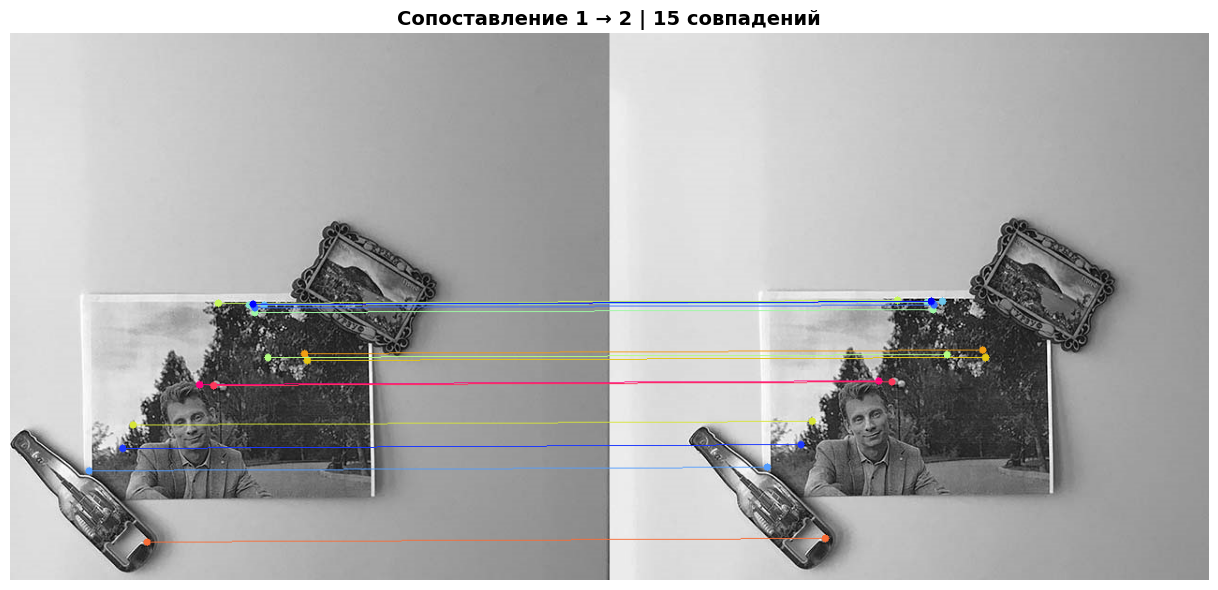

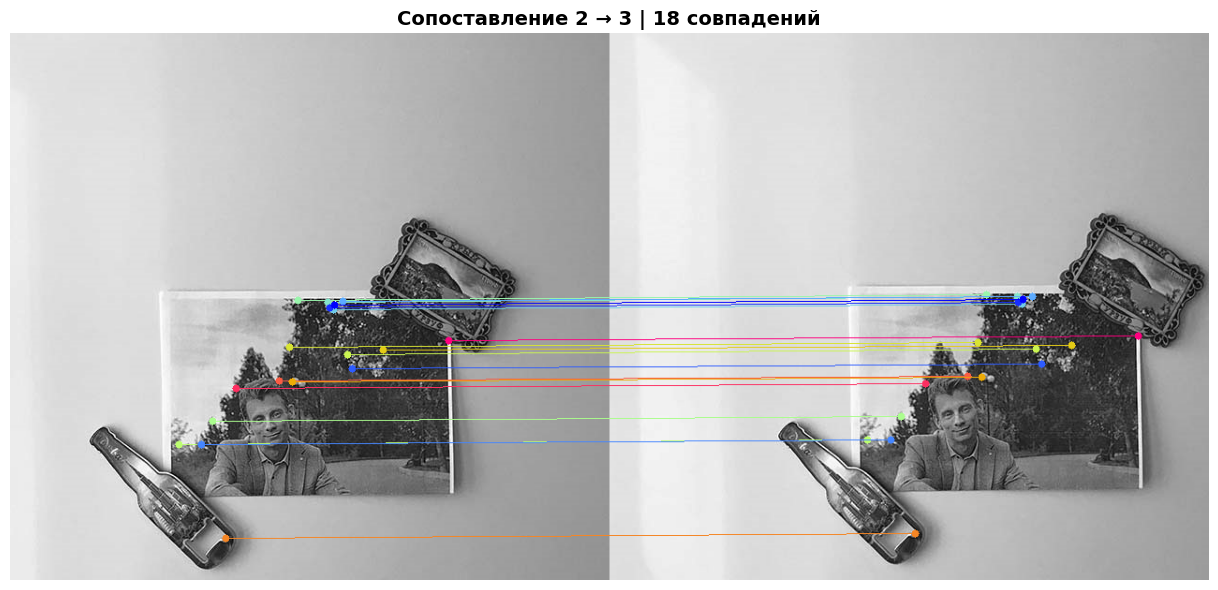

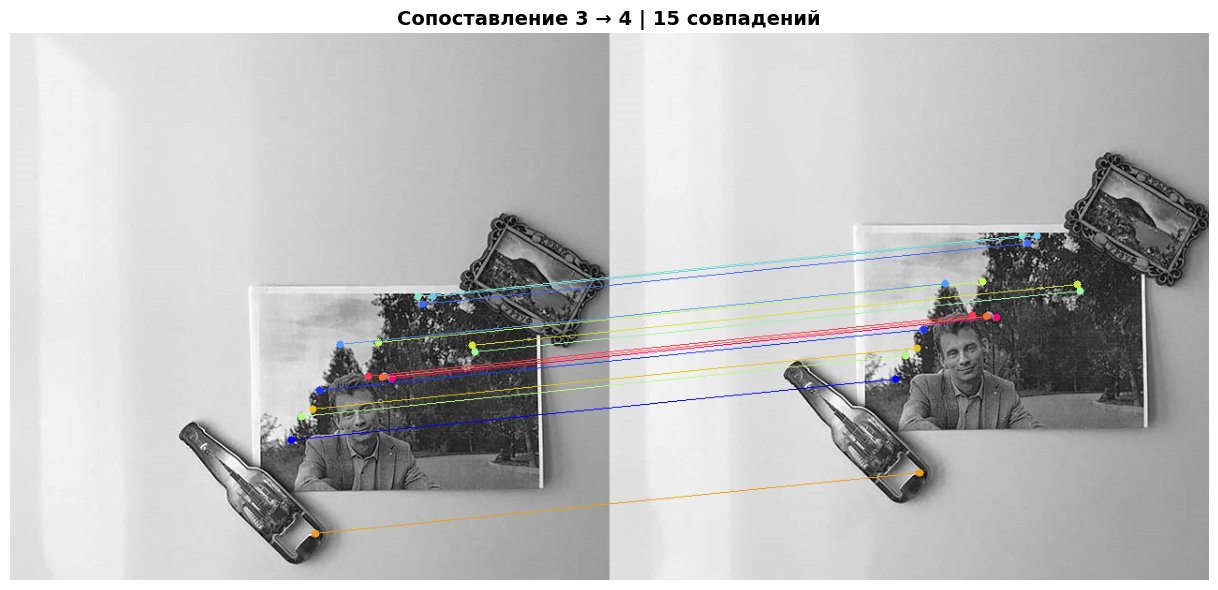

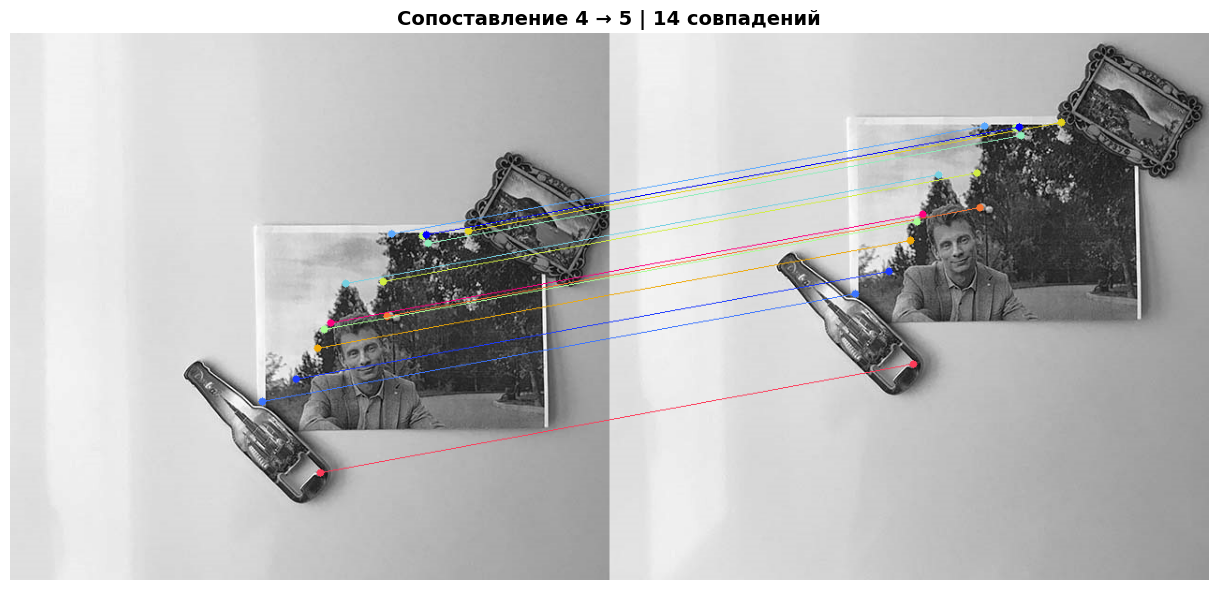

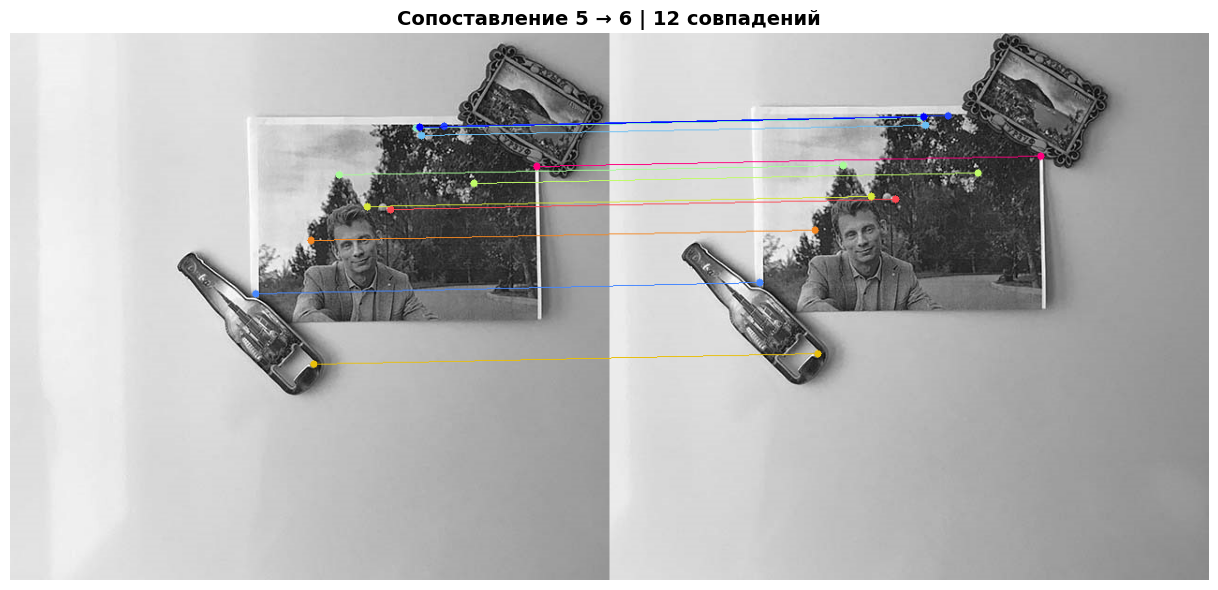

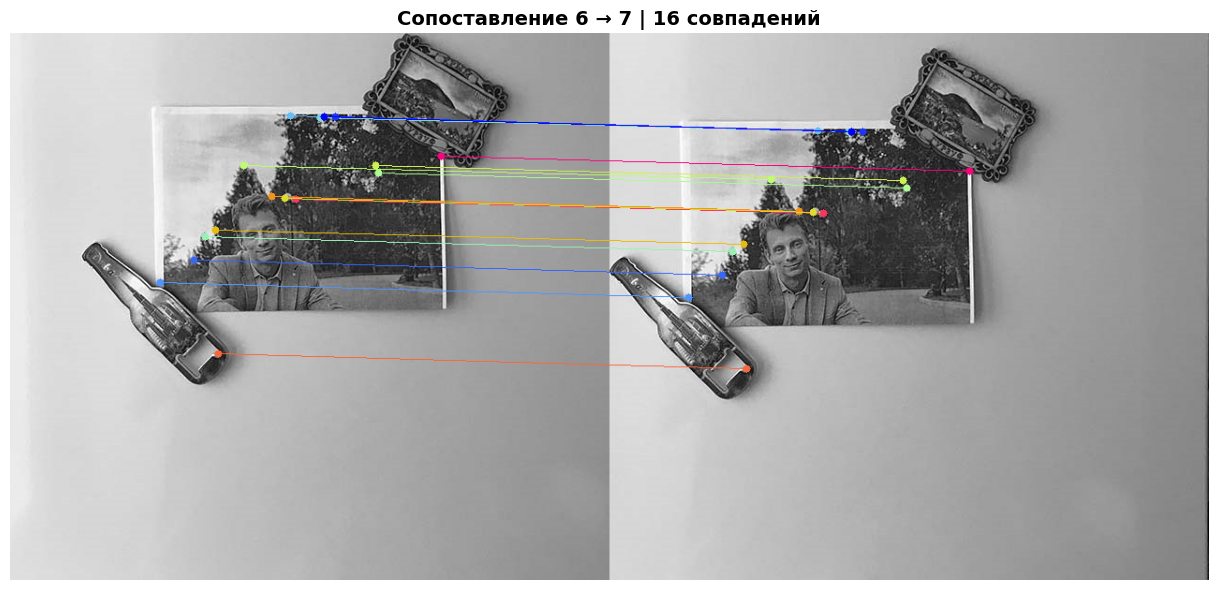

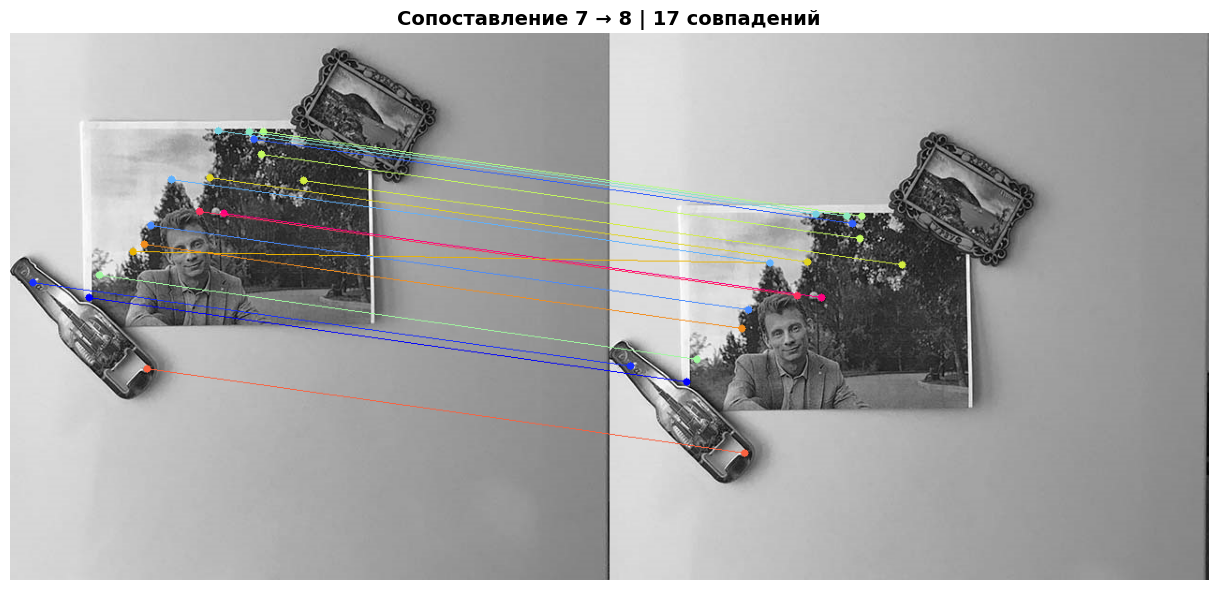

In [53]:
all_matches = []

for i in range(len(gray_images) - 1):
    if len(all_descriptors[i]) > 0 and len(all_descriptors[i+1]) > 0:
        matches = match_descriptors(all_descriptors[i], all_descriptors[i+1])
        all_matches.append(matches)
        print(f"   Пара {i+1}-{i+2}: {len(matches)} сопоставленных точек")
    else:
        all_matches.append([])
        print(f"   Пара {i+1}-{i+2}: нет дескрипторов для сопоставления")

# Функция для визуализации сопоставлений
def visualize_matches(img1, img2, corners1, corners2, matches, title=""):
    """Визуализация сопоставленных точек"""
    if len(matches) == 0:
        print("   Нет сопоставлений для визуализации")
        return
    
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    
    # Создаем объединенное изображение
    combined = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
    combined[:h1, :w1] = img1
    combined[:h2, w1:w1+w2] = img2
    
    # Конвертируем в цветное
    combined_color = cv.cvtColor(combined, cv.COLOR_GRAY2BGR)
    
    # Рисуем сопоставления
    colors = plt.cm.rainbow(np.linspace(0, 1, min(20, len(matches))))
    
    for idx, (i, j, dist) in enumerate(matches[:20]):  # Первые 20
        color = tuple(int(c * 255) for c in colors[idx][:3])
        
        x1, y1 = corners1[i]
        x2, y2 = corners2[j]
        
        # Рисуем точки
        cv.circle(combined_color, (int(x1), int(y1)), 4, color, -1)
        cv.circle(combined_color, (int(x2) + w1, int(y2)), 4, color, -1)
        
        # Рисуем линию
        cv.line(combined_color, (int(x1), int(y1)), 
                (int(x2) + w1, int(y2)), color, 1)
    
    plt.figure(figsize=(15, 6))
    plt.imshow(cv.cvtColor(combined_color, cv.COLOR_BGR2RGB))
    plt.title(f'{title} | {len(matches)} совпадений', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for i, matches in enumerate(all_matches):
    if len(matches) > 0:
        visualize_matches(gray_images[i], gray_images[i+1], 
                         corners[i], corners[i+1], 
                         matches, f'Сопоставление {i+1} → {i+2}')

In [54]:
def estimate_transform(matches, corners1, corners2):
    """
    Оценка аффинного преобразования методом наименьших квадратов
    
    Параметры:
    matches: список сопоставлений (idx1, idx2, distance)
    corners1, corners2: координаты ключевых точек
    
    Возвращает:
    matrix: матрица преобразования 2x3
    translation: вектор смещения (dx, dy)
    """
    if len(matches) < 3:
        return None, (0, 0)
    
    # Собираем соответствующие точки
    pts1 = []
    pts2 = []
    
    for i, j, _ in matches:
        pts1.append(corners1[i])
        pts2.append(corners2[j])
    
    pts1 = np.array(pts1)
    pts2 = np.array(pts2)
    
    # Вычисляем среднее смещение
    translation = np.mean(pts2 - pts1, axis=0)
    
    matrix = np.array([[1, 0, translation[0]],
                       [0, 1, translation[1]]])
    
    return matrix, translation

In [57]:
def ransac_transform(matches, corners1, corners2, n_iterations=100, threshold=10.0):
    """
    Оценка преобразования с использованием RANSAC
    
    Параметры:
    matches: список сопоставлений
    corners1, corners2: координаты ключевых точек
    n_iterations: количество итераций RANSAC
    threshold: порог для определения inliers
    
    Возвращает:
    best_transform: лучшая матрица преобразования
    best_translation: лучшее смещение
    best_inliers: индексы inliers
    """
    if len(matches) < 3:
        return None, (0, 0), []
    best_inliers = []
    best_translation = (0, 0)
    for _ in range(n_iterations):
        
        # Выбираем 3 случайных сопоставления
        sample_idx = random.sample(range(len(matches)), 3)
        sample_matches = [matches[i] for i in sample_idx]

        # Оцениваем преобразование
        _, translation = estimate_transform(sample_matches, corners1, corners2)
        
        # Находим inliers
        inliers = []
        for idx, (i, j, _) in enumerate(matches):
            x1, y1 = corners1[i]
            x2, y2 = corners2[j]
            # Вычисляем ошибку
            error = np.sqrt((x2 - x1 - translation[0])**2 + 
                          (y2 - y1 - translation[1])**2)
            if error < threshold:
                inliers.append(idx)
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_translation = translation
    # Переоцениваем по всем inliers
    if len(best_inliers) >= 3:
        inlier_matches = [matches[i] for i in best_inliers]
        _, best_translation = estimate_transform(inlier_matches, corners1, corners2)
    best_matrix = np.array([[1, 0, best_translation[0]],
                           [0, 1, best_translation[1]]])
    return best_matrix, best_translation, best_inliers

In [58]:
trajectory = [(0, 0)]
transformations = []

for i, matches in enumerate(all_matches):
    if len(matches) >= 3:
        matrix, translation, inliers = ransac_transform(
            matches, corners[i], corners[i+1]
        )
        
        last_point = trajectory[-1]
        new_point = (last_point[0] + translation[0], 
                    last_point[1] + translation[1])
        trajectory.append(new_point)
        transformations.append(matrix)
        
        print(f"   Кадр {i+1} → {i+2}:")
        print(f"      Смещение: Δx = {translation[0]:.2f}, Δy = {translation[1]:.2f}")
        print(f"      Inliers: {len(inliers)}/{len(matches)}")
        print(f"      Позиция: ({new_point[0]:.2f}, {new_point[1]:.2f})")
    else:
        trajectory.append(trajectory[-1])
        transformations.append(None)
        print(f"   Кадр {i+1} → {i+2}: недостаточно совпадений ({len(matches)})")

   Кадр 1 → 2:
      Смещение: Δx = 84.33, Δy = -3.53
      Inliers: 15/15
      Позиция: (84.33, -3.53)
   Кадр 2 → 3:
      Смещение: Δx = 95.44, Δy = -5.33
      Inliers: 18/18
      Позиция: (179.78, -8.87)
   Кадр 3 → 4:
      Смещение: Δx = 5.27, Δy = -65.00
      Inliers: 15/15
      Позиция: (185.04, -73.87)
   Кадр 4 → 5:
      Смещение: Δx = -7.00, Δy = -115.43
      Inliers: 14/14
      Позиция: (178.04, -189.30)
   Кадр 5 → 6:
      Смещение: Δx = -101.92, Δy = -11.00
      Inliers: 12/12
      Позиция: (76.13, -200.30)
   Кадр 6 → 7:
      Смещение: Δx = -76.50, Δy = 15.69
      Inliers: 16/16
      Позиция: (-0.37, -184.61)
   Кадр 7 → 8:
      Смещение: Δx = -1.69, Δy = 89.81
      Inliers: 16/17
      Позиция: (-2.06, -94.80)


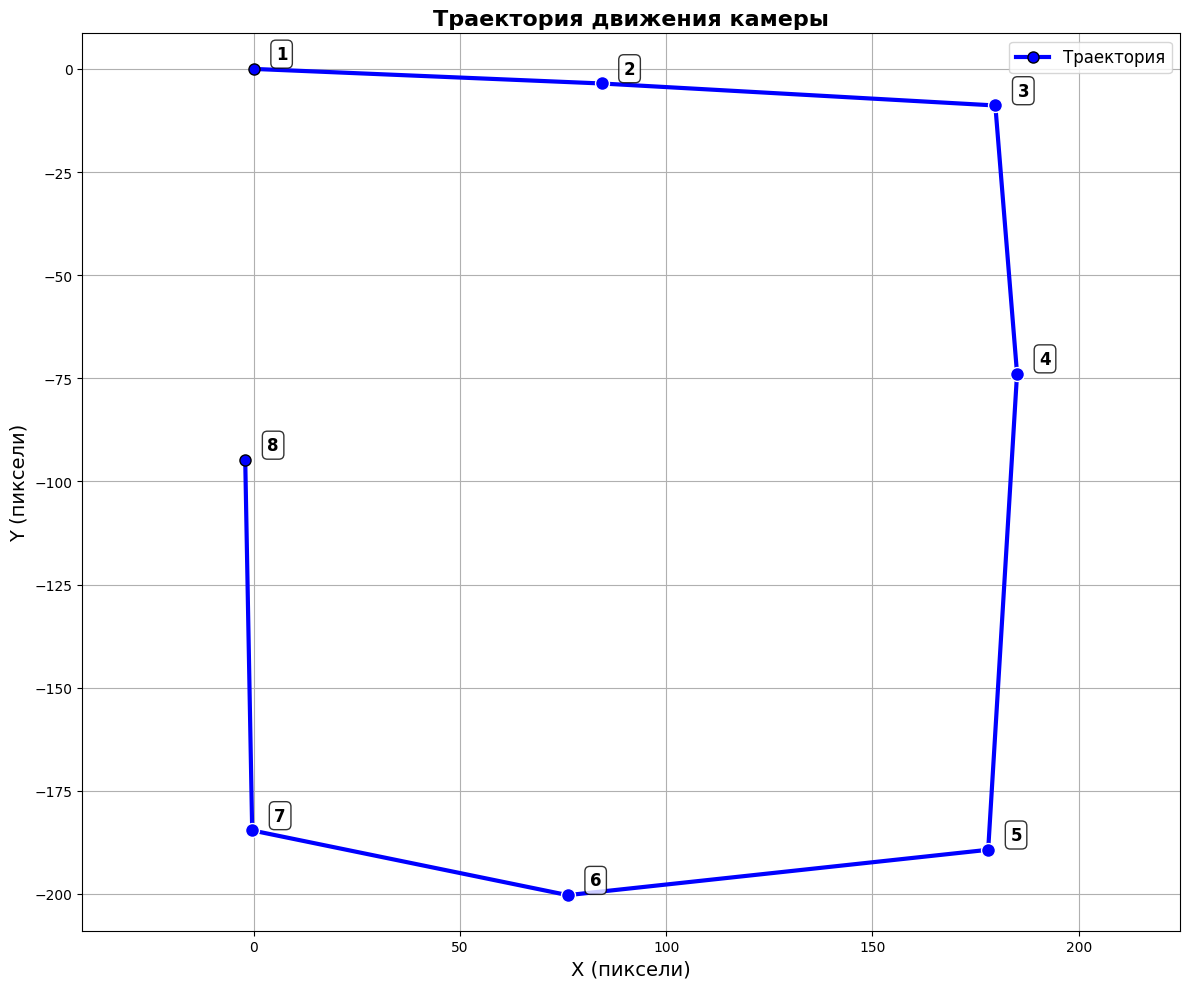

In [59]:
trajectory_np = np.array(trajectory)  # Преобразуем в numpy массив

plt.figure(figsize=(12, 10))

# Рисуем траекторию
plt.plot(trajectory_np[:, 0], trajectory_np[:, 1], 'b-o', linewidth=3, markersize=8, 
         label='Траектория', markeredgecolor='black', markeredgewidth=1)

# Добавляем промежуточные точки
plt.scatter(trajectory_np[1:-1, 0], trajectory_np[1:-1, 1], c='blue', s=100, 
            edgecolors='white', linewidth=1, zorder=3)

# Добавляем номера кадров
for i, (x, y) in enumerate(trajectory_np):
    plt.annotate(f'{i+1}', (x+2, y-1), xytext=(10, 10), 
                textcoords='offset points', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',facecolor='white', alpha=0.8, edgecolor='black'))

plt.grid(True, alpha=1, linestyle='-')
plt.xlabel('X (пиксели)', fontsize=14)
plt.ylabel('Y (пиксели)', fontsize=14)
plt.title('Траектория движения камеры', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.axis('equal')
plt.tight_layout()

plt.savefig('trajectory.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()